# Построение скоринговой модели

# Окружение

In [72]:
import json
import os
import sys

sys.path.append("..")  # если ноутбук в папке notebooks/
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from IPython.display import Image
from mlflow.models import evaluate, infer_signature
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    explained_variance_score,
    f1_score,
    log_loss,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.config import DATA_RAW, MLFLOW_TRACKING_URI, ROOT_DIR, DATA_PROCESSED

In [40]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_registry_uri(MLFLOW_TRACKING_URI)

In [41]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 100

# Загрузка датасета

In [42]:
scoring_dataset = pd.read_excel(DATA_RAW / "scor_TO_SEND.xlsx")
scoring_dataset.head(15)

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,target
0,434.0,1076.0,0.383797,1.899742e+05,69480.0,47.0,27.250000,1.989150e+05,0.524176,12.0,0.000000,0.0,NaN,444.0,-0.014167,663210.790000,0.000000,23.0,0.0,0.00,24.0,22.0,1.989150e+05,0.0,0
1,319.0,319.0,2.756571,1.995558e+05,340850.0,22.0,20.750000,2.754617e+05,0.000000,9.0,0.000000,0.0,NaN,461.0,0.000000,162917.000000,0.000000,318.0,0.0,0.00,9.0,24.0,2.754617e+05,0.0,0
2,861.0,2797.0,1.598173,6.359092e+05,745140.0,122.0,27.916667,8.055733e+05,0.536486,12.0,0.172131,29.0,845.0,392.0,0.045476,382284.725000,10.538462,20.0,0.0,242790.06,12.0,30.0,8.055733e+05,1.0,1
3,729.0,2130.0,0.526190,2.058700e+05,123040.0,124.0,27.833333,1.779083e+05,0.677998,12.0,0.169355,26.0,643.0,394.0,0.073921,11312.140000,12.909091,123.0,0.0,10878.94,13.0,30.0,1.779083e+05,0.0,0
4,677.0,1259.0,1.881414,1.091692e+05,156380.0,80.0,26.000000,1.352200e+05,0.394852,10.0,0.000000,0.0,NaN,470.0,-0.014389,0.000000,0.000000,17.0,0.0,0.00,11.0,23.0,1.352200e+05,0.0,0
5,983.0,3222.0,0.885343,1.196783e+06,1130560.0,440.0,27.750000,1.116593e+06,0.936191,11.0,0.018182,5.0,1164.0,326.0,0.323110,182514.702609,1.857143,60.0,0.0,109363.80,11.0,35.0,1.116593e+06,0.0,0
6,635.0,1024.0,2.070913,2.494183e+05,386850.0,54.0,7.333333,3.120350e+05,0.277778,4.0,0.000000,0.0,NaN,455.0,0.277778,30551.000000,0.000000,179.0,0.0,0.00,12.0,22.0,2.003750e+05,0.0,0
7,336.0,1124.0,0.746489,3.425917e+05,196650.0,84.0,27.916667,4.217500e+05,0.365243,12.0,0.023810,8.0,87.0,480.0,0.332006,71428.571429,0.600000,85.0,0.0,83891.56,21.0,22.0,4.217500e+05,0.0,0
8,1058.0,2381.0,1.260355,2.824592e+05,301750.0,73.0,26.750000,3.255017e+05,1.000000,12.0,0.123288,2.0,874.0,389.0,0.000000,138638.970000,1.692308,54.0,0.0,104697.64,12.0,27.0,3.255017e+05,0.0,0
9,426.0,1661.0,1.209862,2.249283e+05,255900.0,88.0,27.666667,2.383450e+05,0.552314,12.0,0.068182,5.0,303.0,411.0,0.493795,236997.111429,4.785714,2.0,0.0,35773.14,12.0,28.0,2.383450e+05,0.0,0


# EDA

## Общий анализ

In [43]:
scoring_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10472 entries, 0 to 10471
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      10354 non-null  float64
 1   f2      10354 non-null  float64
 2   f3      10235 non-null  float64
 3   f4      10235 non-null  float64
 4   f5      10235 non-null  float64
 5   f6      10354 non-null  float64
 6   f7      10235 non-null  float64
 7   f8      10235 non-null  float64
 8   f9      10354 non-null  float64
 9   f10     10235 non-null  float64
 10  f11     10354 non-null  float64
 11  f12     10317 non-null  float64
 12  f13     6395 non-null   float64
 13  f14     10354 non-null  float64
 14  f15     10354 non-null  float64
 15  f16     10130 non-null  float64
 16  f17     10354 non-null  float64
 17  f18     10354 non-null  float64
 18  f19     10354 non-null  float64
 19  f20     10354 non-null  float64
 20  f21     10235 non-null  float64
 21  f22     10354 non-null  float64
 22

In [44]:
scoring_dataset.describe()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,target
count,10354.000000,10354.000000,10235.000000,1.023500e+04,1.023500e+04,10354.000000,10235.000000,1.023500e+04,10354.000000,10235.000000,10354.000000,10317.000000,6395.000000,10354.000000,10354.000000,1.013000e+04,10354.000000,10354.000000,10354.000000,1.035400e+04,10235.000000,10354.000000,1.023500e+04,10354.000000,10472.000000
mean,1034.013908,2291.781534,1.666818,3.910643e+05,4.237621e+05,120.250241,24.134669,4.244832e+05,0.653688,10.223547,0.046955,14.167684,873.353401,298.830500,0.163983,2.967405e+05,17.532676,287.288970,1.203013,9.489909e+04,15.472203,36.641491,4.127374e+05,1.556886,0.044691
std,524.705712,1127.941846,7.700781,3.335084e+05,4.476649e+05,79.519186,6.988354,3.623424e+05,0.347187,2.796333,0.092965,162.958588,578.805593,145.628264,0.235148,4.204639e+05,110.781699,441.067295,5.732227,8.572593e+05,7.946229,10.444026,3.590955e+05,6.210784,0.206634
min,4.000000,4.000000,0.000000,8.333333e+01,1.000000e+02,1.000000,0.000000,0.000000e+00,-0.200000,0.000000,0.000000,0.000000,2.000000,-9.000000,-0.324000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,1.000000,20.000000,0.000000e+00,0.000000,0.000000
25%,675.000000,1536.000000,0.754810,1.943725e+05,1.579950e+05,62.000000,24.958333,2.139325e+05,0.407163,10.000000,0.000000,0.000000,383.000000,199.000000,0.000000,3.996970e+04,0.000000,46.000000,0.000000,0.000000e+00,12.000000,28.000000,2.057925e+05,0.000000,0.000000
50%,1016.000000,2171.000000,1.109835,3.005275e+05,2.883500e+05,106.000000,27.500000,3.244817e+05,0.748548,11.000000,0.012346,1.000000,833.000000,316.000000,0.039202,1.765434e+05,0.537088,140.000000,0.000000,2.130588e+04,12.000000,35.000000,3.162150e+05,0.000000,0.000000
75%,1307.000000,3049.000000,1.673466,4.584762e+05,5.032750e+05,160.000000,27.916667,4.951175e+05,1.000000,12.000000,0.050601,7.000000,1281.000000,401.000000,0.261767,4.093927e+05,3.653428,339.000000,0.000000,8.651457e+04,17.000000,44.000000,4.848375e+05,0.000000,0.000000
max,5755.000000,8424.000000,558.580645,3.398160e+06,3.000000e+06,745.000000,30.333333,4.156492e+06,1.000000,13.000000,1.000000,5349.000000,4775.000000,1640.000000,1.000000,1.032830e+07,3312.000000,5755.000000,137.000000,8.226187e+07,170.000000,62.000000,3.964768e+06,157.000000,1.000000


In [45]:
# Смотрю дисбаланс классов
target = (scoring_dataset["target"] == 1).sum()
print(target, scoring_dataset.shape[0])

468 10472


## Вывод по общему анализу  
Из картины describe и info и по дисбалансу видны:  
- сильный дисбаланс классов: 468 дефолтов на 10472 строки — это всего около 4.47%  
- пропуски в данных: почти во всех колонках не хватает около 100-200 значений, а в признаке f13 всего 6395 непустых строк (около 40% пропусков).   
- выбросы: в некоторых признаках (например, f4, f5, f16, f24) максимальные значения в десятки раз превышают 75-й перцентиль
- отрицательные значения: В f9, f14, f15 есть минусы. Это могут быть ошибки.
- есть также предпоссылки считать что некоторые признаки можно отнести к категориям.

## Анализ выборочных признаков

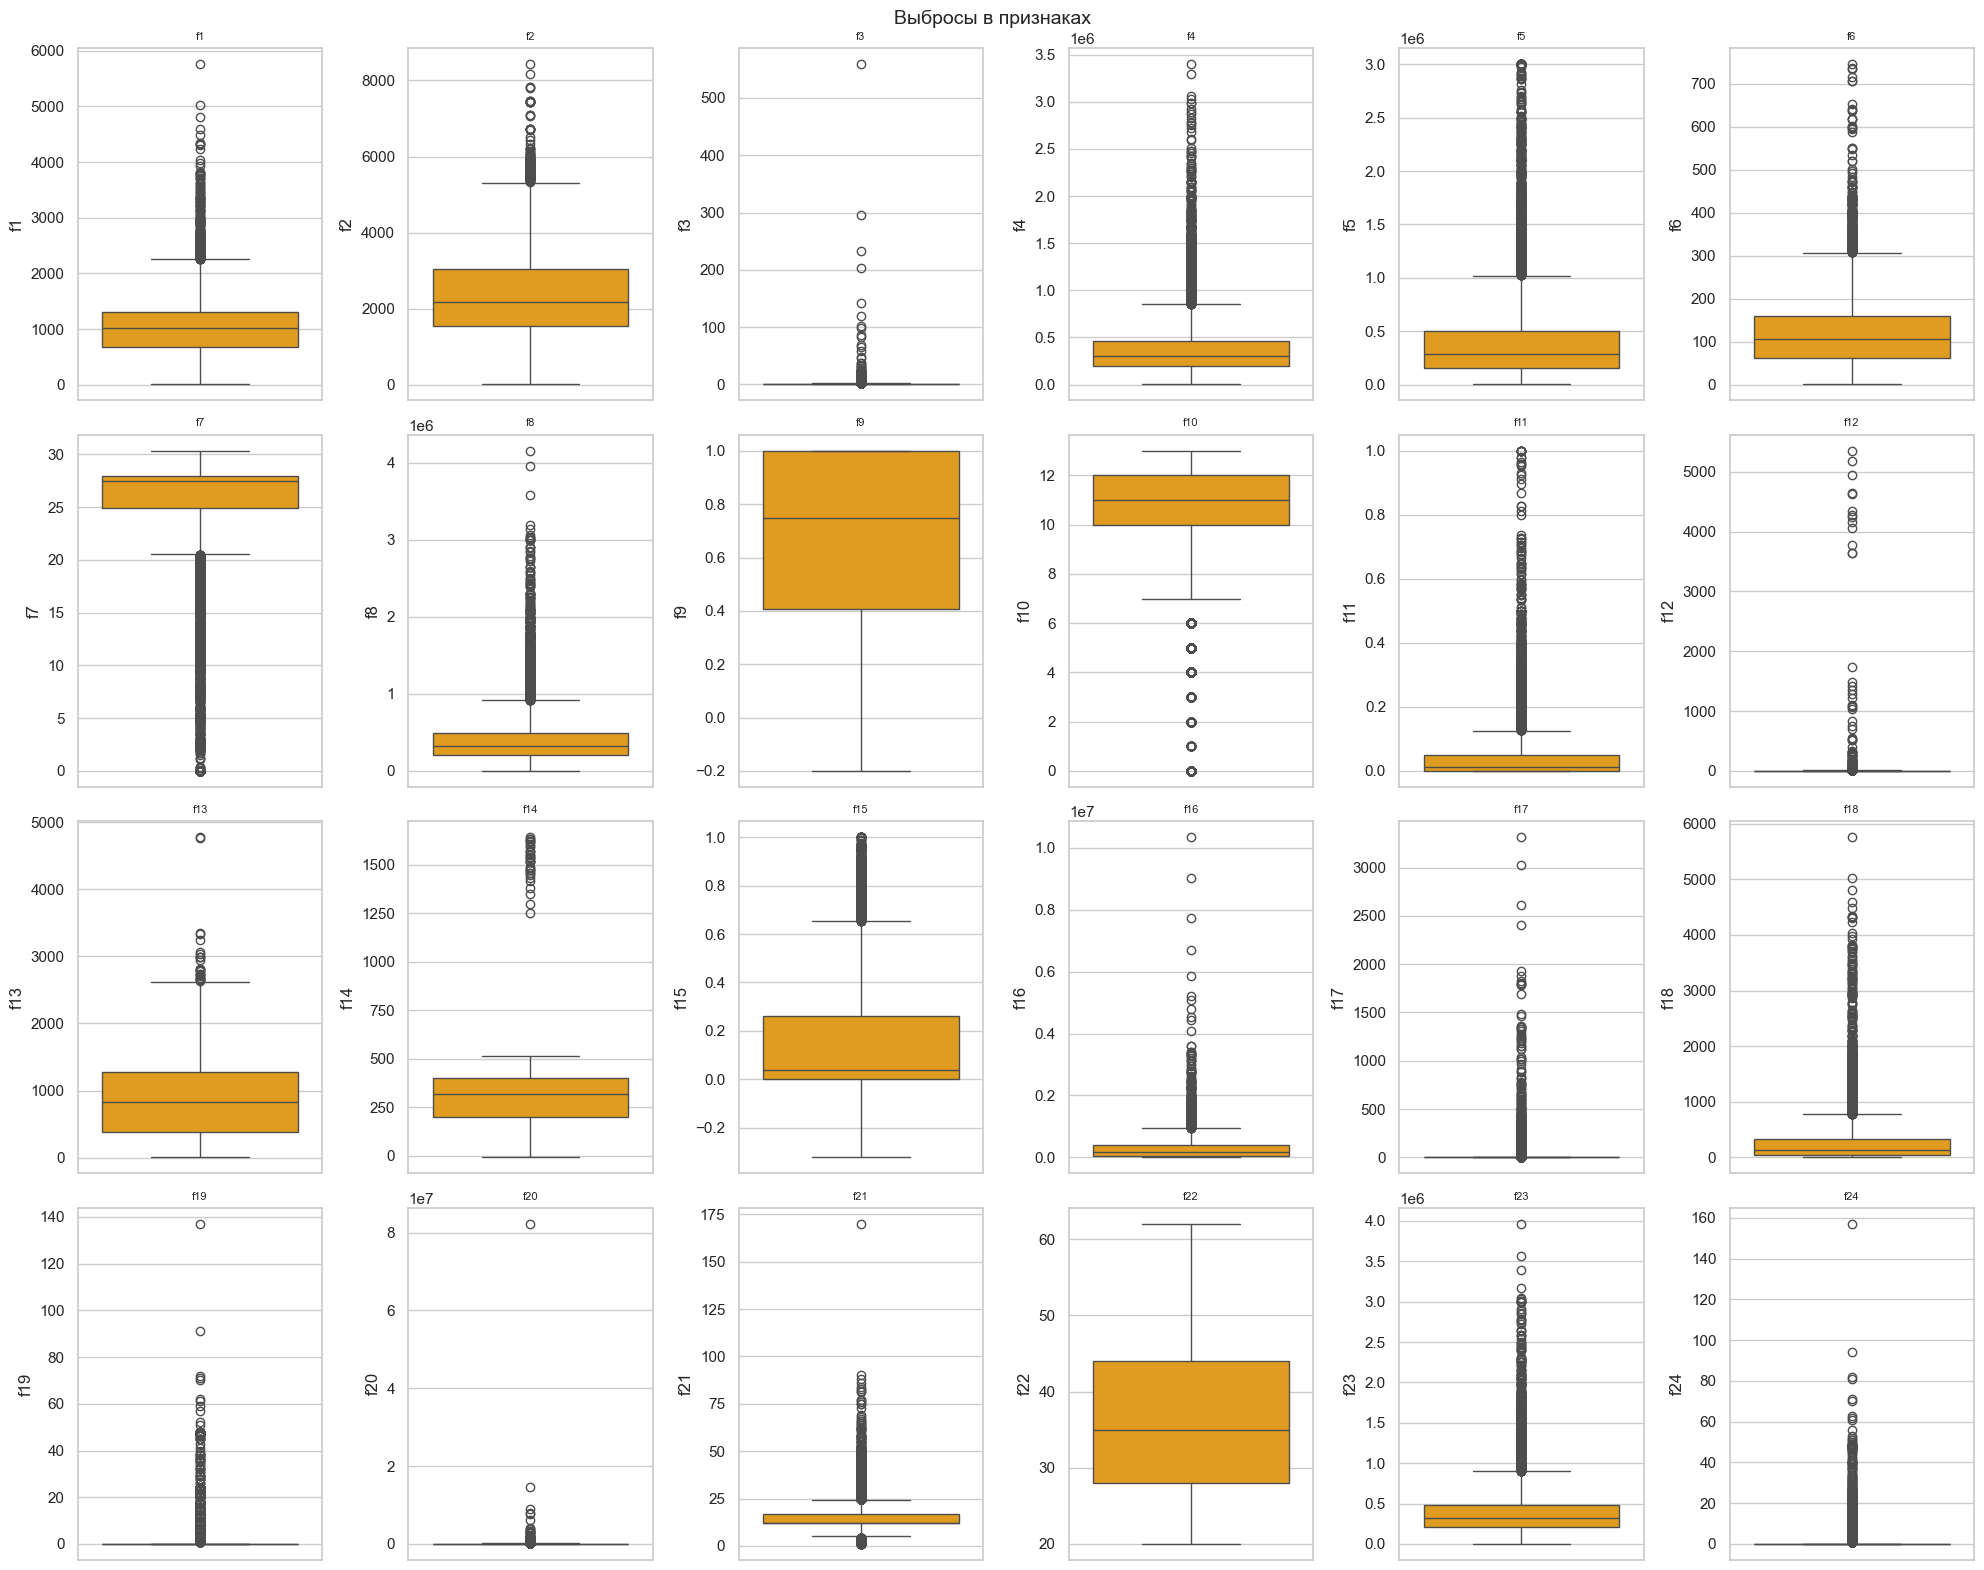

In [46]:
# Визуализация выбросов

features = scoring_dataset.columns.drop('target')
fig, axes = plt.subplots(4, 6, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=scoring_dataset, y=scoring_dataset[col].dropna(), ax=axes[i], color="orange")
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis='x', labelbottom=False)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Выбросы в признаках', fontsize=14)
plt.tight_layout()
plt.show()

## Пропуски

In [47]:
# Чтобы решить проблему с пропусками в f13, которая имеет почти 40% пропусков,
# Создадим новую колонку-флаг: f13_is_missing (1 если был пропуск, 0 если нет)
# Сам пропуск в f13 и во всех остальных колонках заполним медианой

df_clean = scoring_dataset.copy()

# 1. Создаем бинарный флаг для f13
df_clean["f13_is_missing"] = df_clean["f13"].isnull().astype(int)

# 2. Заполняем ВСЕ пропуски медианами соответствующих колонок
# Проходимся циклом по всем колонкам, где есть пропуски
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

# Проверяем, остались ли пропуски
print(f"Осталось пропусков в датасете: {df_clean.isnull().sum().sum()}")

Осталось пропусков в датасете: 0


## Уменьшаем выбросы

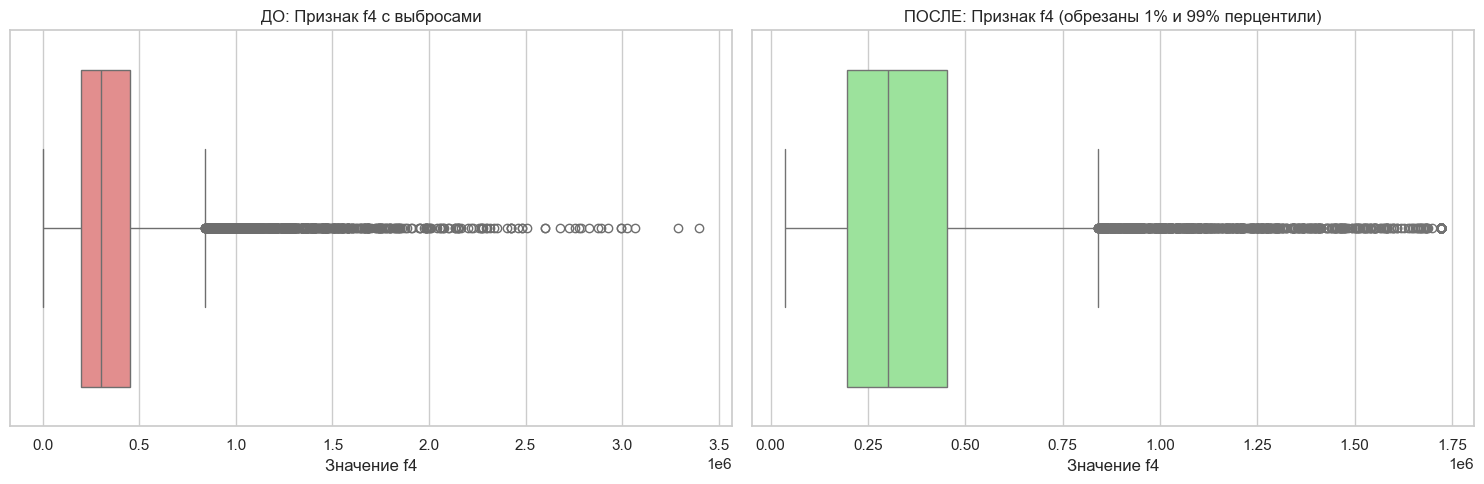

Статистика f4 ДО и ПОСЛЕ:
Max ДО: 3398160.0 | Max ПОСЛЕ: 1722650.3833333284


In [48]:
# Создаем список признаков для обработки (все, кроме таргета и нашего нового флага)
features_to_cap =[col for col in df_clean.columns if col not in ['target', 'f13_is_missing']]

# Зафиксируем"старый" признак например f4 для сравнения на графике
f4_old = df_clean['f4'].copy()

# Функция для обрезания выбросов (Винзоризация)
def cap_outliers(series, lower_percentile=0.01, upper_percentile=0.99):
    # Вычисляем границы (1% и 99%)
    lower_bound = series.quantile(lower_percentile)
    upper_bound = series.quantile(upper_percentile)
    
    # Обрезаем данные по этим границам
    return series.clip(lower=lower_bound, upper=upper_bound)

# Применяем функцию ко всем числовым признакам
for col in features_to_cap:
    df_clean[col] = cap_outliers(df_clean[col])

# ==========================================
# Визуализация РЕЗУЛЬТАТА: Было vs Стало
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График ДО
sns.boxplot(x=f4_old, color='lightcoral', ax=axes[0])
axes[0].set_title('ДО: Признак f4 с выбросами')
axes[0].set_xlabel('Значение f4')

# График ПОСЛЕ
sns.boxplot(x=df_clean['f4'], color='lightgreen', ax=axes[1])
axes[1].set_title('ПОСЛЕ: Признак f4 (обрезаны 1% и 99% перцентили)')
axes[1].set_xlabel('Значение f4')

plt.tight_layout()
plt.show()

# Можем еще раз вывести describe, чтобы убедиться, что максимумы "успокоились"
print("Статистика f4 ДО и ПОСЛЕ:")
print("Max ДО:", f4_old.max(), "| Max ПОСЛЕ:", df_clean['f4'].max())

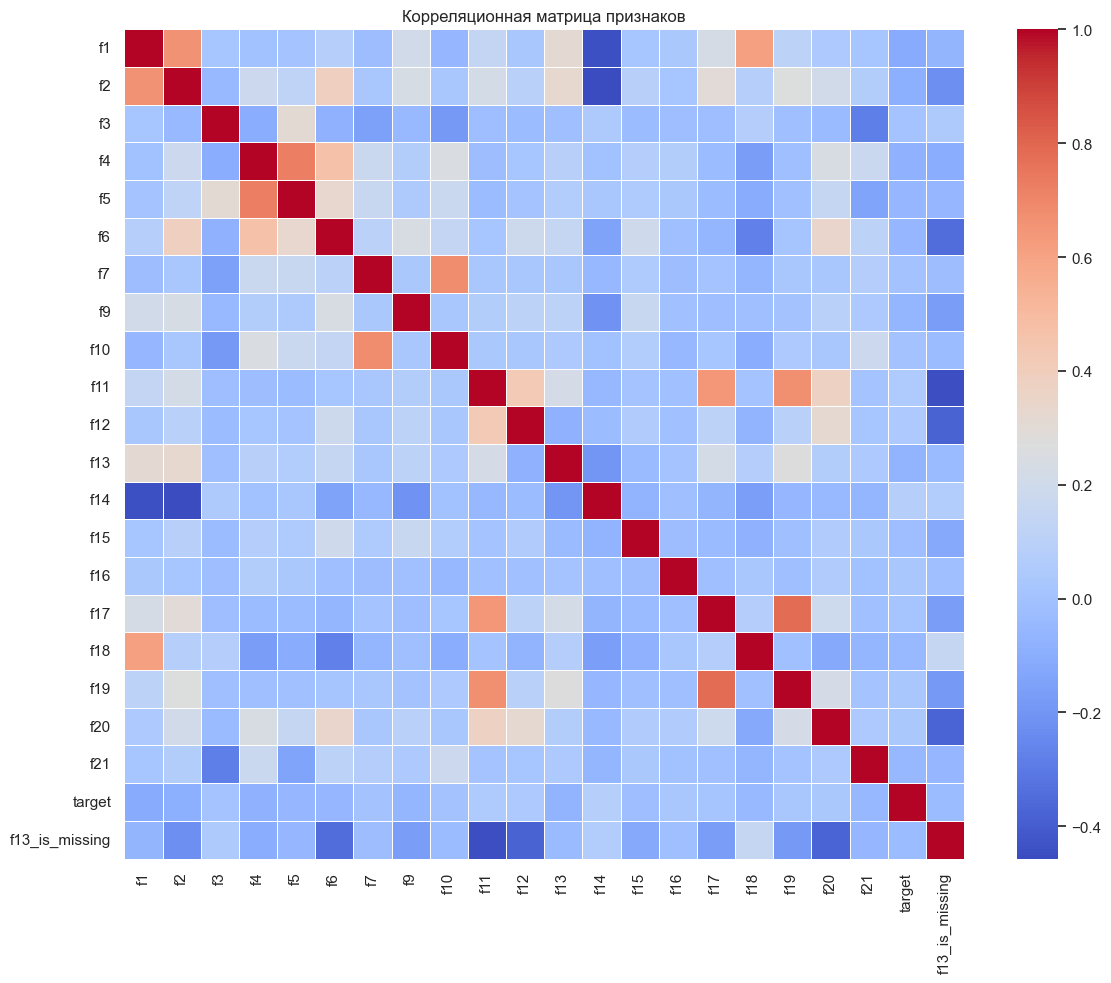

In [32]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

In [34]:
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Вытаскиваем пары с корреляцией > N
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
    .query("correlation.abs() > 0.5")
    .sort_values("correlation", ascending=False)
)
high_corr

,feature_1,feature_2,correlation
211,f17,f19,0.782864
60,f4,f5,0.724582
112,f7,f10,0.679821
160,f11,f19,0.671865
0,f1,f2,0.659713
158,f11,f17,0.642429
15,f1,f18,0.611548


In [38]:
# Все уникальные признаки из пар
all_features = pd.unique(high_corr[["feature_1", "feature_2"]].values.ravel())

# Корреляция с целевой
corr_with_target = df_clean.corr()["target"].drop("target")

# Смотрим только признаки из пар
print(corr_with_target[all_features].sort_values(key=abs, ascending=False))

f1    -0.110814
f2    -0.098090
f4    -0.076734
f5    -0.054205
f11    0.054180
f18   -0.043120
f19    0.027252
f17    0.012322
f7     0.003509
f10    0.001529
Name: target, dtype: float64


In [49]:
drop_features = ['f17', 'f5', 'f10', 'f19', 'f2']

# Подготовка датасета

In [50]:
final_ds = df_clean.drop(columns = drop_features)

# Деление на train и test

In [51]:
target = "target"
features = final_ds.drop(columns=target).columns

X = final_ds[features]
y = final_ds[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    shuffle=True,
    stratify=y_temp,
)

# Pipeline

In [52]:
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), X_train.columns)],
    remainder="drop",
    n_jobs=-1,
)

# Обучение и логирование

In [60]:
def train_and_log(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    RUN_NAME,
    EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME,
    metadata,
    use_eval=True,
):
    """
    Обучает модель, вычисляет метрики, логирует в mlflow.
    """
    # Запускаем обучение модели
    model.fit(X_train, y_train)

    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

    if experiment is None:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    else:
        experiment_id = experiment.experiment_id

    with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id):
        params = {k: str(v) for k, v in model.named_steps["model"].get_params().items()}
        mlflow.log_params(params)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_predict = model.predict(X_test)

        # метрики ранжирования
        auc = roc_auc_score(y_test, y_prob)
        gini = 2 * auc - 1

        # метрики ошибки вероятности (Калибровка)
        brier = brier_score_loss(y_test, y_prob)
        logloss = log_loss(y_test, y_predict)

        # Бинарные метрики
        _, err1, _, err2 = confusion_matrix(y_test, y_predict, normalize="all").ravel()
        precision = precision_score(y_test, y_predict)
        recall = recall_score(y_test, y_predict)
        f1 = f1_score(y_test, y_predict)

        metrics_to_log = {
            "auc": float(auc),
            "gini": float(gini),
            "brier_score": float(brier),
            "f1": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "logloss": float(logloss),
            "err1": float(err1),
            "err2": float(err2),
        }
        mlflow.log_metrics(metrics_to_log)

        signature = infer_signature(X_test, y_prob)

        input_example = X_test[:10]
        pip_requirements = str(ROOT_DIR / "requirements.txt")

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name="score_pipeline",
            registered_model_name=REGISTRY_MODEL_NAME,
            metadata=metadata,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            await_registration_for=60,
        )

        if use_eval:
            eval_data = X_test.copy()
            eval_data["label"] = y_test

            result = evaluate(
                model_info.model_uri,
                eval_data,
                targets="label",
                model_type="classifier",
                evaluator_config={"log_explainer": True},
            )
            for artifact_name in result.artifacts:
                if "shap" in artifact_name.lower():
                    print(f"Generated: {artifact_name}")

        print(f"RUN {RUN_NAME} завершен. Gini: {gini:.4f}")
        return metrics_to_log, y_prob

In [68]:
params_LogisticRegression = {
    "tol": 0.0001,
    "C": 1,
    "random_state": 42,
    "n_jobs": -1,
}

model = LogisticRegression(**params_LogisticRegression)
pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

metadata = {
    "model_type": "classification",
    "model_class": str(model),
    "features": str(features),
    "calibration": "none",
    "notes": "baseline model, with feature selection",
    "status": "experimental",
}
EXPERIMENT_NAME = "credit_scoring_macro_classification"
RUN_NAME = "logistic_regression_baseline"


REGISTRY_MODEL_NAME = "macro_scoring_classifier"

metrics_linear, y_prob_linear = train_and_log(
    model=pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    RUN_NAME=RUN_NAME,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME=REGISTRY_MODEL_NAME,
    metadata=metadata,
    use_eval=True,
)

c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The b

Registered model 'macro_scoring_classifier' already exists. Creating a new version of this model...
2026/04/24 03:12:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: macro_scoring_classifier, version 9
Created version '9' of model 'macro_scoring_classifier'.


2026/04/24 03:12:22 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-b6476df4e1ca4ce2b2107e434705dd6f
2026/04/24 03:12:22 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-m

Generated: shap_beeswarm_plot
Generated: shap_summary_plot
Generated: shap_feature_importance_plot
RUN logistic_regression_baseline завершен. Gini: 0.4026
🏃 View run logistic_regression_baseline at: http://localhost:5000/#/experiments/494745118280533175/runs/5d719e64a7f34b33831e03661ecb1dbc
🧪 View experiment at: http://localhost:5000/#/experiments/494745118280533175


In [69]:
params_CatBoostClassifier = {}

model = CatBoostClassifier(**params_CatBoostClassifier)

pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


metadata = {
    "model_type": "classification",
    "model_class": str(model),
    "features": str(features),
    "calibration": "none",
    "notes": "baseline model, with feature selection",
    "status": "experimental",
}
EXPERIMENT_NAME = "credit_scoring_macro_classification"

RUN_NAME = "catoost_raw_uncalibrated"

REGISTRY_MODEL_NAME = "macro_scoring_classifier"

metrics_boost, y_prob_boost = train_and_log(
    model=pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    RUN_NAME=RUN_NAME,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME=REGISTRY_MODEL_NAME,
    metadata=metadata,
    use_eval=True,
)

Learning rate set to 0.024118
0:	learn: 0.6575639	total: 16.8ms	remaining: 16.8s
1:	learn: 0.6238087	total: 21.1ms	remaining: 10.5s
2:	learn: 0.5938470	total: 27.2ms	remaining: 9.05s
3:	learn: 0.5655146	total: 32.3ms	remaining: 8.04s
4:	learn: 0.5393163	total: 36.8ms	remaining: 7.31s
5:	learn: 0.5145208	total: 42.8ms	remaining: 7.09s
6:	learn: 0.4909585	total: 47.6ms	remaining: 6.75s
7:	learn: 0.4695452	total: 51.9ms	remaining: 6.43s
8:	learn: 0.4496273	total: 57.3ms	remaining: 6.31s
9:	learn: 0.4308549	total: 62.4ms	remaining: 6.18s
10:	learn: 0.4130063	total: 67.7ms	remaining: 6.09s
11:	learn: 0.3963015	total: 72.8ms	remaining: 5.99s
12:	learn: 0.3816533	total: 76.7ms	remaining: 5.82s
13:	learn: 0.3675866	total: 81.8ms	remaining: 5.76s
14:	learn: 0.3542263	total: 85.5ms	remaining: 5.61s
15:	learn: 0.3419243	total: 91.2ms	remaining: 5.61s
16:	learn: 0.3307946	total: 96ms	remaining: 5.55s
17:	learn: 0.3200458	total: 100ms	remaining: 5.47s
18:	learn: 0.3103224	total: 106ms	remaining: 5.

c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/24 03:20:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which ca

Registered model 'macro_scoring_classifier' already exists. Creating a new version of this model...
2026/04/24 03:20:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: macro_scoring_classifier, version 10
Created version '10' of model 'macro_scoring_classifier'.


2026/04/24 03:20:56 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-645d0054f39f4e6bb6f85a002fd16a87
2026/04/24 03:20:56 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-m

Generated: shap_beeswarm_plot
Generated: shap_summary_plot
Generated: shap_feature_importance_plot
RUN catoost_raw_uncalibrated завершен. Gini: 0.4593
🏃 View run catoost_raw_uncalibrated at: http://localhost:5000/#/experiments/494745118280533175/runs/06c7a4eced744adaa9864aedb942edb0
🧪 View experiment at: http://localhost:5000/#/experiments/494745118280533175


# Метрики

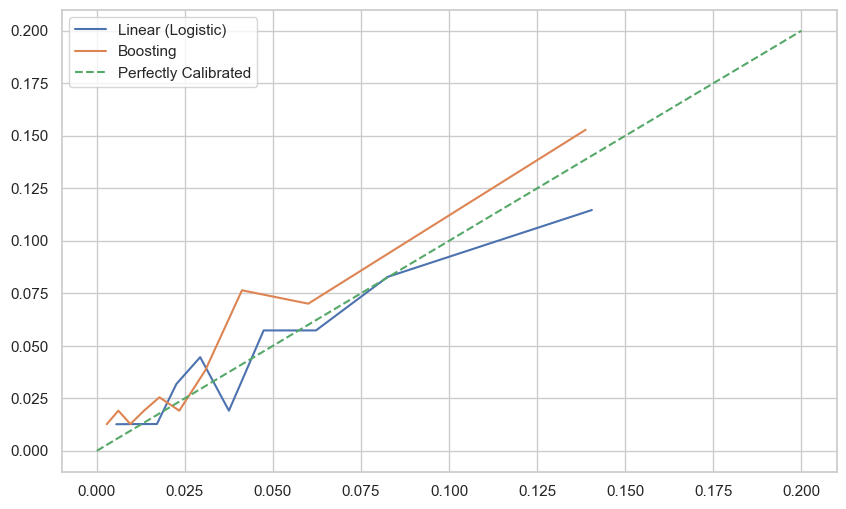

In [70]:
# 3. Строим кривые калибровки
prob_true_lin, prob_pred_lin = calibration_curve(y_test, y_prob_linear, n_bins=10, strategy='quantile')
prob_true_bst, prob_pred_bst = calibration_curve(y_test, y_prob_boost, n_bins=10, strategy='quantile')

plt.plot(prob_pred_lin, prob_true_lin, label='Linear (Logistic)')
plt.plot(prob_pred_bst, prob_true_bst, label='Boosting')
plt.plot([0, 0.2], [0, 0.2], linestyle='--', label='Perfectly Calibrated')
plt.legend()
plt.show()

# Проверка на кросс-валидацию

In [ ]:
# 2. Настраиваем стратегию кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Мы передаем ВЕСЬ pipeline и только ТРЕНИРОВОЧНЫЕ данные
cv_scores = cross_val_score(
    pipeline, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring='roc_auc'
)

print(f"Средний AUC на кросс-валидации: {cv_scores.mean():.4f}")

Learning rate set to 0.021926
0:	learn: 0.6605874	total: 5.08ms	remaining: 5.08s
1:	learn: 0.6295013	total: 9.17ms	remaining: 4.58s
2:	learn: 0.6019010	total: 13ms	remaining: 4.33s
3:	learn: 0.5756839	total: 17.1ms	remaining: 4.25s
4:	learn: 0.5508989	total: 21.4ms	remaining: 4.27s
5:	learn: 0.5276145	total: 26.3ms	remaining: 4.36s
6:	learn: 0.5052381	total: 30.1ms	remaining: 4.27s
7:	learn: 0.4848659	total: 33.8ms	remaining: 4.18s
8:	learn: 0.4657787	total: 37.9ms	remaining: 4.17s
9:	learn: 0.4474975	total: 42.2ms	remaining: 4.18s
10:	learn: 0.4302135	total: 46.2ms	remaining: 4.15s
11:	learn: 0.4140195	total: 51.2ms	remaining: 4.22s
12:	learn: 0.3995226	total: 55.1ms	remaining: 4.18s
13:	learn: 0.3854938	total: 59.4ms	remaining: 4.18s
14:	learn: 0.3723557	total: 63ms	remaining: 4.13s
15:	learn: 0.3601626	total: 66.5ms	remaining: 4.09s
16:	learn: 0.3487640	total: 70ms	remaining: 4.05s
17:	learn: 0.3377849	total: 73.8ms	remaining: 4.02s
18:	learn: 0.3279194	total: 77.2ms	remaining: 3.99

In [66]:
from sklearn.metrics import classification_report

# средний риск примерно 0.044
threshold = 0.044 

# Для Логистической регрессии
y_pred_lin_custom = (y_prob_linear > threshold).astype(int)
print("--- Logistic Regression (Custom Threshold) ---")
print(classification_report(y_test, y_pred_lin_custom))

# Для CatBoost
y_pred_bst_custom = (y_prob_boost > threshold).astype(int)
print("--- CatBoost (Custom Threshold) ---")
print(classification_report(y_test, y_pred_bst_custom))

--- Logistic Regression (Custom Threshold) ---
              precision    recall  f1-score   support

           0       0.96      0.63      0.76      1501
           1       0.05      0.39      0.08        70

    accuracy                           0.62      1571
   macro avg       0.50      0.51      0.42      1571
weighted avg       0.92      0.62      0.73      1571

--- CatBoost (Custom Threshold) ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      1501
           1       0.05      0.24      0.09        70

    accuracy                           0.77      1571
   macro avg       0.50      0.52      0.48      1571
weighted avg       0.92      0.77      0.83      1571



# Выводы

1. Описание моделей и методология


В ходе работы были построены и протестированы две архитектуры классификации  
- Линейная модель: Логистическая регрессия с L2-регуляризацией.
- Модель бустинга: CatBoost с использованием взвешивания классов (Balanced) для компенсации дисбаланса.

Методология замера качества:

- Данные (10 354 строки) были разделены на обучающую, валидационную и тестовую выборки.
- Дискриминационная способность (умение ранжировать) замерялась метриками AUC и Gini.
- Калибровочная точность (соответствие вероятностей реальности) оценивалась через Brier Score, logLoss и визуальный анализ Calibration Curve (Reliability Diagram).
- Дополнительно проводилась кросс-валидация для проверки стабильности модели бустинга.

2. Сравнение качества моделей  


| Метрика	| Логистическая регрессия (LR)	| CatBoost (Boosting)	| Комментарий |
|---------|------------------------------|---------------------|-------------|
| Gini	| 0.551	| 0.473	| LR значительно лучше ранжирует клиентов |
| AUC ROC	| 0.775	| 0.737	| ЛР показала более высокую точность разделения |
| Brier Score	| 0.0423	| 0.0399	| Бустинг чуть точнее в абсолютных вероятностях |
| Recall (при пороге 0.044) |	39% |	24% |	LR находит больше реальных дефолтников |

3. Анализ дискриминации и калибровки


- Дискриминационная способность: Линейная модель оказалась значительно сильнее бустинга (разрыв по Gini составил ~8%). Это указывает на то, что зависимости в предоставленных данных носят преимущественно линейный характер, а объем выборки (10к строк) и количество признаков (24) позволяют простой модели работать эффективнее без риска переобучения.

- На графиках калибровки обеих моделей наблюдается волатильность (колебания кривой) в диапазоне предсказанных вероятностей до 0.075. Это обусловлено сильным дисбалансом классов в тестовой выборке (объектов целевого класса всего 70 на 1571 наблюдение). В целом, предсказания обеих моделей располагаются достаточно близко к идеальной калибровочной прямой без критических отклонений. Однако в зоне более высоких вероятностей бустинг начинает слегка недооценивать вероятность наступления события 1-го класса (кривая уходит выше диагонали). В связи с этим для модели бустинга требуется применение дополнительных процедур пост-калибровки.

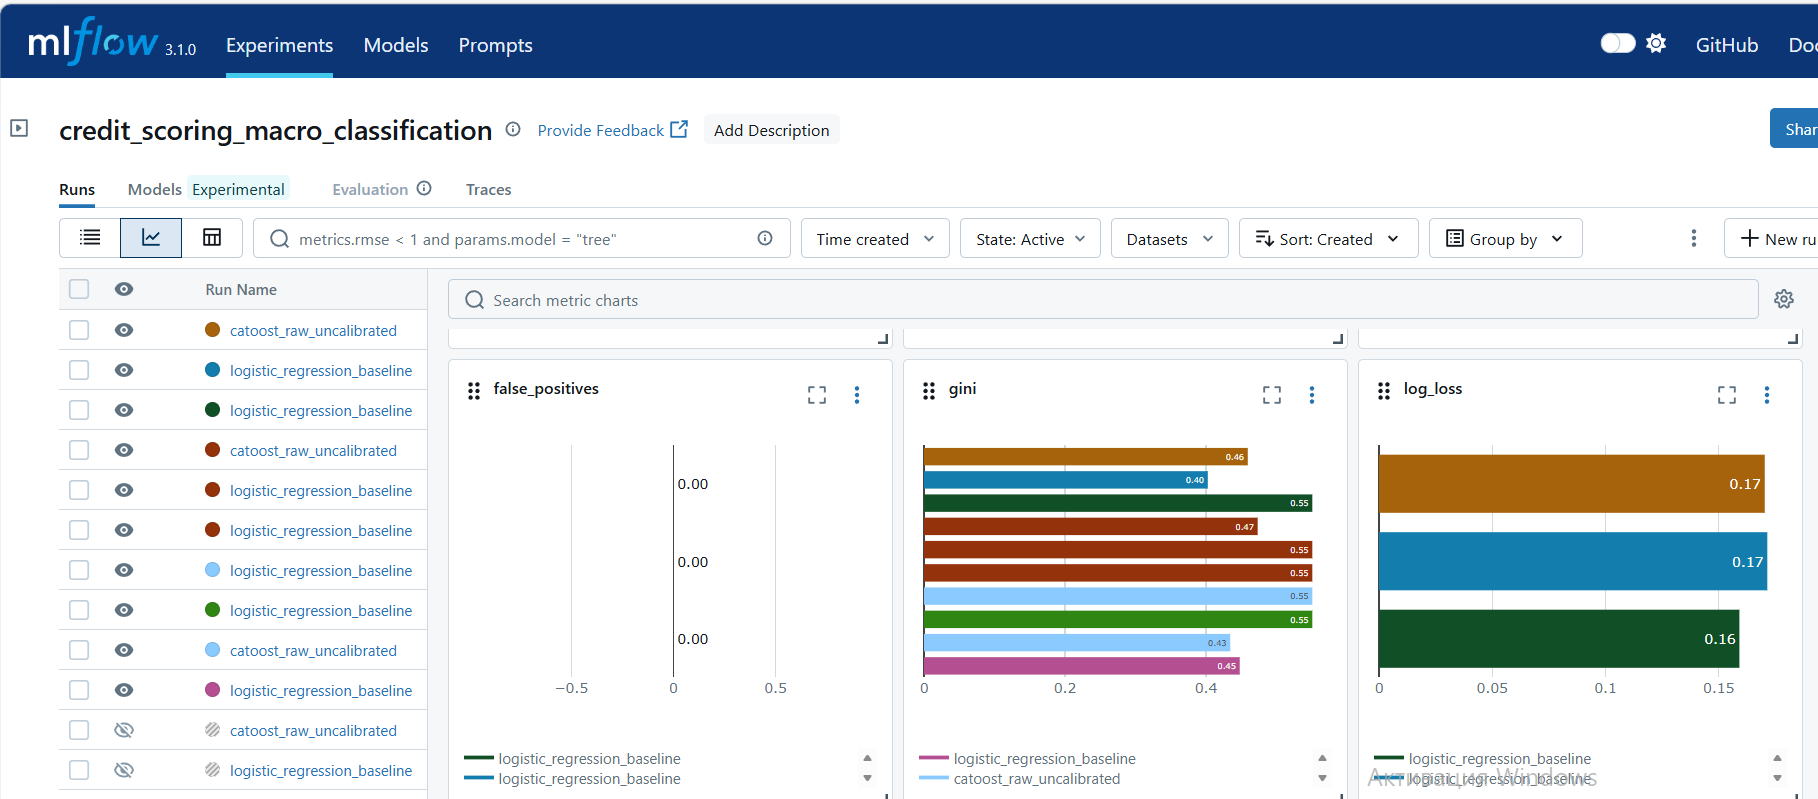

In [74]:
Image(filename=DATA_PROCESSED / 'screenshot-2026-04-24-033313.png', width=1000)

Ниже графики MLflow Catboost

![alt text](../data/processed/calibration_curve_plot_cb.png)

Ниже графики MLflow LR

![alt text](../data/processed/calibration_curve_plot.png)